In [1]:
# ==================================================
# 1. IMPORTS
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit # <-- AJOUT POUR LA VALIDATION CROISÉE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)






In [2]:
# ==================================================
# 2. CHARGEMENT DATASET
# ==================================================
df = pd.read_csv("dataset_clean_ready.csv")

df = df.sort_values(["Household_ID_encoded"]).reset_index(drop=True)

print("Shape :", df.shape)

Shape : (90001, 6)


In [3]:
# ==================================================
# 3. CRÉATION DE LA TARGET
# ==================================================
df["target_next_day"] = (
    df.groupby("Household_ID_encoded")["Energy_Consumption_kWh"]
    .shift(-1)
)

df_model = df.dropna(subset=["target_next_day"]).copy()

print("Shape après target :", df_model.shape)

Shape après target : (77144, 7)


In [4]:
# ==================================================
# 4. FEATURES & TARGET
# ==================================================
FEATURES = [
    "Energy_Consumption_kWh",
    "Household_Size",
    "Avg_Temperature_C",
    "Has_AC",
    "Peak_Hours_Usage_kWh"
]

TARGET = "target_next_day"

X = df_model[FEATURES]
y = df_model[TARGET]

In [5]:
# ==================================================
# 5. TRAIN / TEST SPLIT (Pour le modèle final)
# ==================================================
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train size :", len(X_train))
print("Test size :", len(X_test))

Train size : 61715
Test size : 15429


In [6]:
# ==================================================
# 6. XGBOOST MODEL (Modèle Final)
# ==================================================
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("✅ Modèle XGBoost final entraîné")

# ==================================================
# 7. PREDICTIONS (Modèle Final)
# ==================================================
y_pred = xgb_model.predict(X_test)


✅ Modèle XGBoost final entraîné


In [7]:
# ==================================================
# 8. EVALUATION (Modèle Final)
# ==================================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("📊 PERFORMANCE XGBOOST (Split 80/20)")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

📊 PERFORMANCE XGBOOST (Split 80/20)
MAE  : 1.0851
RMSE : 1.4202
R²   : 0.9261


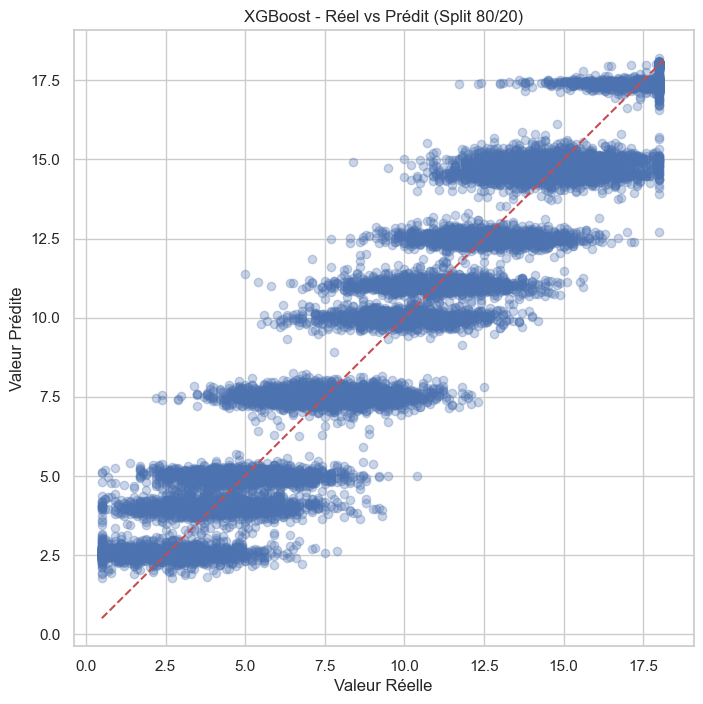

In [8]:
# ==================================================
# 9. REAL VS PREDICTED (Modèle Final)
# ==================================================
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valeur Réelle")
plt.ylabel("Valeur Prédite")
plt.title("XGBoost - Réel vs Prédit (Split 80/20)")
plt.show()


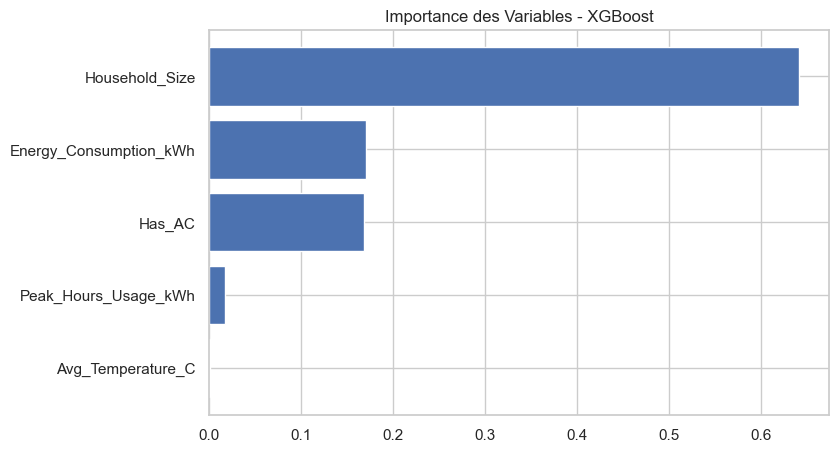

                  Feature  Importance
1          Household_Size    0.641486
0  Energy_Consumption_kWh    0.171155
3                  Has_AC    0.168314
4    Peak_Hours_Usage_kWh    0.017626
2       Avg_Temperature_C    0.001419


In [9]:
# ==================================================
# 10. FEATURE IMPORTANCE (Modèle Final)
# ==================================================
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Importance des Variables - XGBoost")
plt.show()

print(importance.sort_values("Importance", ascending=False))

In [10]:
# ==================================================
# 11. VALIDATION CROISÉE TEMPORELLE (TimeSeriesSplit)
# ==================================================
print("\n" + "=" * 50)
print("🔄 DÉMARRAGE DE LA VALIDATION CROISÉE TEMPORELLE")
print("=" * 50)

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Entraînement sur le fold
    fold_model = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    fold_model.fit(X_tr, y_tr)
    y_te_pred = fold_model.predict(X_te)

    # Calcul des métriques
    mae_scores.append(mean_absolute_error(y_te, y_te_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, y_te_pred)))
    r2_scores.append(r2_score(y_te, y_te_pred))

    print(f"Fold {fold+1} | MAE: {mae_scores[-1]:.4f} | R²: {r2_scores[-1]:.4f}")

# Statistiques finales de la validation croisée
mae_scores = np.array(mae_scores)
r2_scores = np.array(r2_scores)
rmse_scores = np.array(rmse_scores)

print("\n" + "=" * 50)
print("📊 RÉSULTATS MOYENS (TimeSeriesSplit 5 Folds)")
print("=" * 50)
print(f"MAE moyen  : {np.mean(mae_scores):.4f}  (Écart-type : {np.std(mae_scores):.4f})")
print(f"RMSE moyen : {np.mean(rmse_scores):.4f}  (Écart-type : {np.std(rmse_scores):.4f})")
print(f"R² moyen   : {np.mean(r2_scores):.4f}       (Écart-type : {np.std(r2_scores):.4f})")
print("=" * 50)


🔄 DÉMARRAGE DE LA VALIDATION CROISÉE TEMPORELLE
Fold 1 | MAE: 1.1014 | R²: 0.9224
Fold 2 | MAE: 1.0926 | R²: 0.9229
Fold 3 | MAE: 1.0770 | R²: 0.9262
Fold 4 | MAE: 1.0858 | R²: 0.9253
Fold 5 | MAE: 1.0870 | R²: 0.9262

📊 RÉSULTATS MOYENS (TimeSeriesSplit 5 Folds)
MAE moyen  : 1.0888  (Écart-type : 0.0081)
RMSE moyen : 1.4285  (Écart-type : 0.0138)
R² moyen   : 0.9246       (Écart-type : 0.0016)


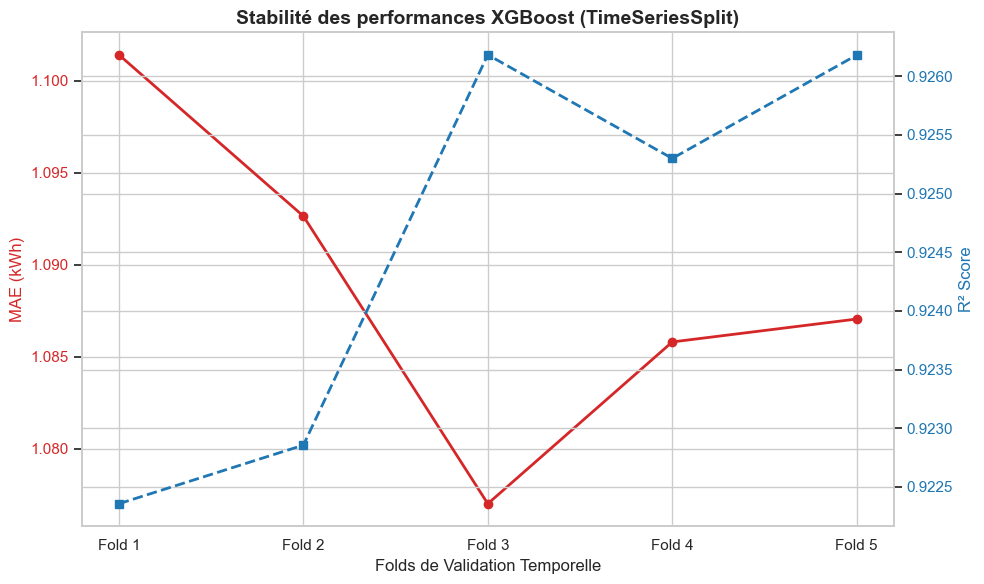

✅ Analyse terminée. Le modèle est robuste et prêt pour l'article !


In [11]:
# ==================================================
# 12. GRAPHIQUE DE STABILITÉ (Pour l'article)
# ==================================================
folds = [f"Fold {i+1}" for i in range(5)]

fig, ax1 = plt.subplots(figsize=(10, 6))

color_mae = 'tab:red'
color_r2 = 'tab:blue'

ax1.set_xlabel('Folds de Validation Temporelle', fontsize=12)
ax1.set_ylabel('MAE (kWh)', color=color_mae, fontsize=12)
ax1.plot(folds, mae_scores, color=color_mae, marker='o', linestyle='-', linewidth=2, label='MAE')
ax1.tick_params(axis='y', labelcolor=color_mae)

ax2 = ax1.twinx()
ax2.set_ylabel('R² Score', color=color_r2, fontsize=12)
ax2.plot(folds, r2_scores, color=color_r2, marker='s', linestyle='--', linewidth=2, label='R²')
ax2.tick_params(axis='y', labelcolor=color_r2)

plt.title("Stabilité des performances XGBoost (TimeSeriesSplit)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

print("✅ Analyse terminée. Le modèle est robuste et prêt pour l'article !")